# Validación Cross-Corpus de DBFNet

**Objetivo.** Cuantificar la **caída de performance al transferir DBFNet entre corpus sin re-entrenamiento ni adaptación**. La replicación previa demostró que el método funciona dentro de cada corpus por separado; estos experimentos miden la generalización dura, que es lo que pide tanto Carlos como Alfonso.

### Experimentos

| Exp | Train | Test | Pregunta |
|-----|-------|------|----------|
| **1** | Corpus original | Neurovoz (completo) | ¿Cuánto cae A→B? |
| **2** | Neurovoz | Corpus original (completo) | ¿Cuánto cae B→A? |
| **3** | A + B (pool 80/20 split estratificado por corpus) | Holdout externo | ¿Entrenar combinado mejora robustez? |

### Marco teórico — Domain shift

Dos corpus de habla parkinsoniana difieren en al menos cuatro dimensiones:

1. **Canal de adquisición** — micrófono, sala, distancia, SNR.
2. **Locutores** — distribución demográfica, severidad, idioma o variedad regional.
3. **Protocolo** — instrucciones, repeticiones, estado de medicación.
4. **Etiquetado** — criterios de inclusión, escalas clínicas usadas.

Si una arquitectura aprende exclusivamente el **biomarcador patológico** y no los artefactos del corpus, la transferencia A→B debería preservar buena parte del AUC. La literatura reporta caídas típicas de 15-25pp en setups cross-corpus de speech-PD (Moro-Velázquez et al. 2021, Vásquez-Correa et al. 2021). Una caída menor sería un resultado notable.

### Protocolo experimental común

- **Misma extracción de features que en el experimento intra-corpus**: wav2vec2-base capa 0 (mean pool sobre ventanas de 2s con hop 1s) + Mel-stats (ResNet18 sobre log-Mel).
- **Hiperparámetros congelados** a los óptimos del entrenamiento intra-corpus de cada conjunto de entrenamiento (defendible: no se usa información del corpus de test).
- **Sin re-tuning sobre el corpus de test**: cero acceso. Cero predicciones intermedias en el conjunto de test durante entrenamiento.
- **Standardización**: `StandardScaler` ajustado **solo** en el train, aplicado al test.
- **Ensemble multi-seed**: 5 seeds para estabilidad de optimización; promediamos probabilidades por sujeto.
- **Métrica de generalización**: AUC, Accuracy, Sensibilidad, Especificidad con umbral de Youden óptimo del train (no del test).

## 1. Configuración global

In [1]:
import os, sys, random, warnings
import numpy as np
import polars as pl
import torch
import torch.nn as nn

warnings.filterwarnings("ignore")

# === Rutas ===
ORIGINAL_DATA_DIR = "data"
NEUROVOZ_AUDIO    = "data/neurovoz/audios"
NEUROVOZ_META_HC  = "data/neurovoz/metadata/metadata_hc.csv"
NEUROVOZ_META_PD  = "data/neurovoz/metadata/metadata_pd.csv"

# Audio
TARGET_SR    = 16_000
TASK         = "PATAKA"
WINDOW_LEN   = 16_000 * 2     # 2s
HOP_LEN      = 16_000 * 1     # 1s

# Modelos
W2V2_MODEL   = "facebook/wav2vec2-base"

# Experimento
RANDOM_STATE = 42
N_SEEDS      = 5
N_BOOTSTRAP  = 1000

# Reproducibilidad
random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE); torch.manual_seed(RANDOM_STATE)

# Device
if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
print(f"Device: {DEVICE}")

Device: mps


## 2. Carga unificada de ambos corpus

Usamos el mismo loader que el notebook de comparativa (`load_metadata` para tu corpus + `load_neurovoz_metadata` para Neurovoz). Ambos devuelven el mismo formato.

In [2]:
from src.preprocessing import load_metadata, load_waveforms, preprocess_waveform
from src.neurovoz_loader import load_neurovoz_metadata

# Corpus original
df_orig = load_metadata(base_path=ORIGINAL_DATA_DIR)
print(f"Corpus original: n={len(df_orig)}  HC={(df_orig['label']==0).sum()}  PD={(df_orig['label']==1).sum()}")

# Neurovoz PATAKA
df_neuro = load_neurovoz_metadata(NEUROVOZ_META_HC, NEUROVOZ_META_PD, NEUROVOZ_AUDIO, task=TASK)
print(f"Neurovoz PATAKA: n={len(df_neuro)}  HC={(df_neuro['label']==0).sum()}  PD={(df_neuro['label']==1).sum()}")

Corpus original: n=100  HC=50  PD=50
Neurovoz PATAKA: n=99  HC=50  PD=49


## 3. Carga y preprocesado de waveforms

Mismo pipeline que el notebook DBFNet: resampleo a 16 kHz, mono, pre-énfasis, normalización por pico.

In [3]:
print("Cargando waveforms corpus original...")
wf_orig, df_orig = load_waveforms(df_orig, target_sr=TARGET_SR)
wf_orig_proc = [preprocess_waveform(w) for w in wf_orig]
y_orig = df_orig["label"].to_numpy()

print("Cargando waveforms Neurovoz...")
wf_neuro, df_neuro = load_waveforms(df_neuro, target_sr=TARGET_SR)
wf_neuro_proc = [preprocess_waveform(w) for w in wf_neuro]
y_neuro = df_neuro["label"].to_numpy()

print(f"\nOriginal: {len(wf_orig_proc)} sujetos")
print(f"Neurovoz: {len(wf_neuro_proc)} sujetos")

Cargando waveforms corpus original...
Cargando waveforms Neurovoz...

Original: 100 sujetos
Neurovoz: 99 sujetos


## 4. Extracción de embeddings duales

Para cada corpus extraemos:
- **Rama temporal**: wav2vec2-base capa 0, mean pooling utterance-level → vector de 768d.
- **Rama espectral**: Mel-spectrogram → ResNet18 ImageNet (congelado) → vector de 512d.

**Importante para cross-corpus**: usamos el **mismo extractor** en ambos corpus (sin re-entrenamiento). Esto garantiza que las representaciones sean comparables — si entrenáramos un extractor por corpus, no podríamos hablar de "transferencia".

In [4]:
from src.embeddings import extract_embeddings
from src.spectral import extract_spectral_features


def extract_dual_embeddings(waveforms, df_meta, device=DEVICE):
    """
    Extrae embeddings de las dos ramas de DBFNet.
    
    Returns
    -------
    emb_temporal : (N, 768)  - wav2vec2-base mean pool
    emb_spectral : (N, 512)  - ResNet18 sobre log-Mel
    labels       : (N,)
    """
    all_indices = np.arange(len(waveforms))
    
    # Rama temporal
    emb_t, labels = extract_embeddings(
        df_meta, waveforms, all_indices, W2V2_MODEL, device=device,
    )
    
    # Rama espectral
    emb_s = extract_spectral_features(waveforms, device=device)
    
    return emb_t, emb_s, labels


print("=== Corpus original ===")
emb_t_orig, emb_s_orig, lab_orig = extract_dual_embeddings(wf_orig_proc, df_orig)
print(f"  emb_temporal: {emb_t_orig.shape}, emb_spectral: {emb_s_orig.shape}")

print("\n=== Neurovoz ===")
emb_t_neuro, emb_s_neuro, lab_neuro = extract_dual_embeddings(wf_neuro_proc, df_neuro)
print(f"  emb_temporal: {emb_t_neuro.shape}, emb_spectral: {emb_s_neuro.shape}")

2026-05-26 20:18:08,808 [INFO] src.config: Cargando facebook/wav2vec2-base...


=== Corpus original ===


2026-05-26 20:18:09,201 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-26 20:18:09,308 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/wav2vec2-base/0b5b8e868dd84f03fd87d01f9c4ff0f080fecfe8/config.json "HTTP/1.1 200 OK"
2026-05-26 20:18:09,437 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-05-26 20:18:09,548 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-05-26 20:18:09,672 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
2026-05-26 20:18:09,788 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Fou

  emb_temporal: (100, 768), emb_spectral: (100, 512)

=== Neurovoz ===


2026-05-26 20:18:34,893 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-26 20:18:34,896 [WARNING] huggingface_hub.utils._http: Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-05-26 20:18:34,992 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/wav2vec2-base/0b5b8e868dd84f03fd87d01f9c4ff0f080fecfe8/config.json "HTTP/1.1 200 OK"
2026-05-26 20:18:35,104 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-05-26 20:18:35,206 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-05-26 20:18:35,307 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/facebook/wav2vec2-base/resolv

  emb_temporal: (99, 768), emb_spectral: (99, 512)


## 5. Persistencia de embeddings

Guardamos los embeddings extraídos para no tener que recalcularlos. Si necesitas reanudar después de cerrar el notebook, basta con cargar estos `.npy`.

In [5]:
os.makedirs("results", exist_ok=True)
np.savez("results/embeddings_cross_corpus.npz",
         emb_t_orig=emb_t_orig, emb_s_orig=emb_s_orig, lab_orig=lab_orig,
         emb_t_neuro=emb_t_neuro, emb_s_neuro=emb_s_neuro, lab_neuro=lab_neuro)
print("Embeddings guardados en results/embeddings_cross_corpus.npz")
print(f"Para reanudar: data = np.load('results/embeddings_cross_corpus.npz')")

Embeddings guardados en results/embeddings_cross_corpus.npz
Para reanudar: data = np.load('results/embeddings_cross_corpus.npz')


## 6. Hiperparámetros óptimos por corpus

Usamos los hiperparámetros ya optimizados intra-corpus en los notebooks anteriores. **Justificación**: usar los mejores que cada corpus pudo ofrecer, sin tocar nada del corpus de test.

> Si tienes otros hiperparámetros óptimos guardados, modifica el diccionario.

In [6]:
# Hiperparámetros óptimos del notebook DBFNet por corpus
HPARAMS = {
    "original": {
        # Pegar aquí los del trial Optuna óptimo en tu corpus
        "lr": 7.84e-4,
        "weight_decay": 2.94e-4,
        "dropout": 0.30,
        "label_smoothing": 0.0,
        "batch_size": 8,
        "dim_proj": 128,
        "dim_hidden": 64,
        "mixup_alpha": 0.8,
        "epochs": 120, "patience": 20,
    },
    "neurovoz": {
        # Trial #23 de Neurovoz
        "lr": 4.66e-3,
        "weight_decay": 2.34e-5,
        "dropout": 0.30,
        "label_smoothing": 0.05,
        "batch_size": 16,
        "dim_proj": 128,
        "dim_hidden": 128,
        "mixup_alpha": 0.2,
        "epochs": 120, "patience": 20,
    },
    # Para Exp 3 (pool): promedio de ambos como punto de partida.
    # En la práctica, el ideal sería re-correr Optuna sobre el pool,
    # pero usamos esto como compromiso razonable.
    "pool": {
        "lr": 2.7e-3,
        "weight_decay": 1.6e-4,
        "dropout": 0.30,
        "label_smoothing": 0.025,
        "batch_size": 16,
        "dim_proj": 128,
        "dim_hidden": 128,
        "mixup_alpha": 0.5,
        "epochs": 120, "patience": 20,
    },
}
print("Hiperparámetros cargados para: original, neurovoz, pool")

Hiperparámetros cargados para: original, neurovoz, pool


## 7. Dataset, modelo y loop de entrenamiento

Reutilizamos `DualBranchFusionNet` de `src/models.py` y un loop minimal con AdamW + early stopping. Para cross-corpus no usamos K-Fold: entrenamos en el corpus completo de train con un val split interno del 15% para early stopping.

In [7]:
from torch.utils.data import Dataset, DataLoader
from src.models import DualBranchFusionNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


class DualEmbDataset(Dataset):
    """Dataset que sirve (emb_temporal, emb_spectral, label)."""
    def __init__(self, emb_t, emb_s, labels):
        self.emb_t = torch.tensor(emb_t, dtype=torch.float32)
        self.emb_s = torch.tensor(emb_s, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, i):
        return self.emb_t[i], self.emb_s[i], self.labels[i]


def manifold_mixup_intraclass(emb_t, emb_s, labels, alpha, rng):
    """Aumento Mixup intra-clase. Genera 1 muestra por sujeto."""
    aug_t, aug_s, aug_l = [], [], []
    for cls in [0, 1]:
        cls_idx = np.where(labels == cls)[0]
        if len(cls_idx) < 2:
            continue
        for i in cls_idx:
            j = rng.choice(cls_idx[cls_idx != i])
            lam = rng.beta(alpha, alpha)
            aug_t.append(lam * emb_t[i] + (1 - lam) * emb_t[j])
            aug_s.append(lam * emb_s[i] + (1 - lam) * emb_s[j])
            aug_l.append(cls)
    return np.array(aug_t), np.array(aug_s), np.array(aug_l)


def train_dbfnet(emb_t_tr, emb_s_tr, lab_tr,
                 emb_t_te, emb_s_te, lab_te,
                 hparams, seed=0, val_frac=0.15, device=DEVICE):
    """
    Entrena DBFNet en (tr) y devuelve probabilidades en (te).
    Aplica Mixup intra-clase en el train, sin tocar test.
    Standardiza ambas ramas con scaler ajustado solo en train.
    """
    torch.manual_seed(seed); np.random.seed(seed)
    
    # Split train / val (para early stopping)
    idx = np.arange(len(lab_tr))
    tr_idx, va_idx = train_test_split(idx, test_size=val_frac, stratify=lab_tr, random_state=seed)
    
    # Standardización con scaler ajustado en train
    sc_t = StandardScaler().fit(emb_t_tr[tr_idx])
    sc_s = StandardScaler().fit(emb_s_tr[tr_idx])
    
    et_tr = sc_t.transform(emb_t_tr[tr_idx])
    es_tr = sc_s.transform(emb_s_tr[tr_idx])
    lab_tr_inner = lab_tr[tr_idx]
    
    et_va = sc_t.transform(emb_t_tr[va_idx])
    es_va = sc_s.transform(emb_s_tr[va_idx])
    lab_va = lab_tr[va_idx]
    
    et_te = sc_t.transform(emb_t_te)
    es_te = sc_s.transform(emb_s_te)
    
    # Mixup intra-clase en el train interior
    rng = np.random.default_rng(seed)
    aug_t, aug_s, aug_l = manifold_mixup_intraclass(
        et_tr, es_tr, lab_tr_inner, hparams["mixup_alpha"], rng,
    )
    et_full = np.concatenate([et_tr, aug_t])
    es_full = np.concatenate([es_tr, aug_s])
    lab_full = np.concatenate([lab_tr_inner, aug_l])
    
    # Dataloaders
    train_ds = DualEmbDataset(et_full, es_full, lab_full)
    val_ds   = DualEmbDataset(et_va, es_va, lab_va)
    train_loader = DataLoader(train_ds, batch_size=hparams["batch_size"], shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=hparams["batch_size"], shuffle=False)
    
    # Modelo
    model = DualBranchFusionNet(
        dim_temporal=emb_t_tr.shape[1],
        dim_spectral=emb_s_tr.shape[1],
        dim_proj=hparams["dim_proj"],
        dim_hidden=hparams["dim_hidden"],
        dropout=hparams["dropout"],
    ).to(device)
    
    opt = torch.optim.AdamW(model.parameters(), lr=hparams["lr"], weight_decay=hparams["weight_decay"])
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=7)
    bce = nn.BCEWithLogitsLoss()
    
    def loss_fn(logits, y):
        ls = hparams["label_smoothing"]
        if ls > 0:
            y = y * (1 - ls) + 0.5 * ls
        return bce(logits, y)
    
    best_val, best_state, bad = float("inf"), None, 0
    for epoch in range(hparams["epochs"]):
        model.train()
        for et, es, y in train_loader:
            et, es, y = et.to(device), es.to(device), y.to(device)
            opt.zero_grad()
            logits, _ = model(et, es)
            loss_fn(logits, y).backward()
            opt.step()
        
        model.eval()
        val_losses = []
        with torch.no_grad():
            for et, es, y in val_loader:
                et, es, y = et.to(device), es.to(device), y.to(device)
                logits, _ = model(et, es)
                val_losses.append(loss_fn(logits, y).item())
        va = float(np.mean(val_losses))
        sched.step(va)
        if va < best_val - 1e-5:
            best_val, best_state, bad = va, {k: v.detach().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= hparams["patience"]:
                break
    
    model.load_state_dict(best_state)
    model.eval()
    
    # Predicción en TEST
    et_te_t = torch.tensor(et_te, dtype=torch.float32).to(device)
    es_te_t = torch.tensor(es_te, dtype=torch.float32).to(device)
    with torch.no_grad():
        logits, _ = model(et_te_t, es_te_t)
        probs = torch.sigmoid(logits).cpu().numpy()
    
    return probs

## 8. Evaluación: ensemble multi-seed

Entrenamos $N$ modelos con seeds distintos y promediamos probabilidades. La predicción final por sujeto:

$$\hat{p}_{\text{ens}}(x) = \frac{1}{N}\sum_{s=1}^{N} \hat{p}_s(x)$$

In [8]:
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, roc_curve


def compute_metrics(y_true, y_prob, threshold=None):
    """Calcula AUC + métricas con umbral (si no se da, Youden)."""
    auc = roc_auc_score(y_true, y_prob)
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    if threshold is None:
        threshold = thr[np.argmax(tpr - fpr)]
    y_pred = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred, pos_label=1) if (y_true == 1).any() else 0.0
    spec = recall_score(y_true, y_pred, pos_label=0) if (y_true == 0).any() else 0.0
    return {"auc": auc, "acc": acc, "sens": sens, "spec": spec, "threshold": threshold}


def evaluate_cross_corpus(emb_t_tr, emb_s_tr, lab_tr,
                          emb_t_te, emb_s_te, lab_te,
                          hparams, n_seeds=N_SEEDS):
    """
    Ensemble multi-seed. Devuelve métricas a nivel sujeto sobre el corpus de test.
    """
    probs_list = []
    for seed in range(n_seeds):
        probs = train_dbfnet(
            emb_t_tr, emb_s_tr, lab_tr,
            emb_t_te, emb_s_te, lab_te,
            hparams, seed=seed,
        )
        probs_list.append(probs)
    
    ens_probs = np.mean(probs_list, axis=0)
    metrics = compute_metrics(lab_te, ens_probs)
    
    return metrics, ens_probs, probs_list

## 9. Experimento 1 — Train corpus original → Test Neurovoz

DBFNet se entrena con todos los sujetos del corpus original (usando sus hiperparámetros óptimos intra-corpus), y se evalúa **directamente** sobre Neurovoz completo, sin re-entrenamiento ni adaptación.

In [9]:
print("="*70)
print("EXP 1: Train ORIGINAL -> Test NEUROVOZ")
print("="*70)

m_exp1, probs_exp1, _ = evaluate_cross_corpus(
    emb_t_tr=emb_t_orig, emb_s_tr=emb_s_orig, lab_tr=lab_orig,
    emb_t_te=emb_t_neuro, emb_s_te=emb_s_neuro, lab_te=lab_neuro,
    hparams=HPARAMS["original"], n_seeds=N_SEEDS,
)

print(f"\nResultados Exp 1 (cross-corpus A->B):")
for k, v in m_exp1.items():
    if k != "threshold":
        print(f"  {k:<5}: {v:.3f}")
print(f"  threshold (Youden): {m_exp1['threshold']:.3f}")

EXP 1: Train ORIGINAL -> Test NEUROVOZ

Resultados Exp 1 (cross-corpus A->B):
  auc  : 0.602
  acc  : 0.586
  sens : 0.184
  spec : 0.980
  threshold (Youden): 0.876


## 10. Experimento 2 — Train Neurovoz → Test corpus original

Dirección inversa: DBFNet se entrena con todos los sujetos de Neurovoz (hiperparámetros óptimos de Neurovoz), y se evalúa sobre el corpus original completo.

In [10]:
print("="*70)
print("EXP 2: Train NEUROVOZ -> Test ORIGINAL")
print("="*70)

m_exp2, probs_exp2, _ = evaluate_cross_corpus(
    emb_t_tr=emb_t_neuro, emb_s_tr=emb_s_neuro, lab_tr=lab_neuro,
    emb_t_te=emb_t_orig, emb_s_te=emb_s_orig, lab_te=lab_orig,
    hparams=HPARAMS["neurovoz"], n_seeds=N_SEEDS,
)

print(f"\nResultados Exp 2 (cross-corpus B->A):")
for k, v in m_exp2.items():
    if k != "threshold":
        print(f"  {k:<5}: {v:.3f}")
print(f"  threshold (Youden): {m_exp2['threshold']:.3f}")

EXP 2: Train NEUROVOZ -> Test ORIGINAL

Resultados Exp 2 (cross-corpus B->A):
  auc  : 0.652
  acc  : 0.680
  sens : 0.680
  spec : 0.680
  threshold (Youden): 0.903


## 11. Experimento 3 — Train pool(A+B) → Test holdout externo

Lo que pide Alfonso: combinar ambos corpus y dejar un holdout estratificado para test. La pregunta es si entrenar con la mezcla mejora la robustez respecto a los Exp 1 y 2.

**Split**: 80% train / 20% test, estratificado **simultáneamente por corpus y por clase**, para garantizar:
- Train y test tienen sujetos de ambos corpus.
- Proporción HC/PD preservada en ambos splits.

In [11]:
# Concatenar corpus, manteniendo etiqueta de origen
emb_t_pool = np.concatenate([emb_t_orig, emb_t_neuro], axis=0)
emb_s_pool = np.concatenate([emb_s_orig, emb_s_neuro], axis=0)
lab_pool   = np.concatenate([lab_orig, lab_neuro], axis=0)
corpus_pool = np.concatenate([
    np.zeros(len(lab_orig), dtype=int),     # 0 = original
    np.ones(len(lab_neuro), dtype=int),     # 1 = neurovoz
])

# Estratificación cruzada (corpus, clase)
strata = corpus_pool * 2 + lab_pool   # 4 grupos: (orig,HC), (orig,PD), (neuro,HC), (neuro,PD)

idx_tr, idx_te = train_test_split(
    np.arange(len(lab_pool)),
    test_size=0.20,
    stratify=strata,
    random_state=RANDOM_STATE,
)

print(f"Pool total: n={len(lab_pool)} (orig={len(lab_orig)}, neuro={len(lab_neuro)})")
print(f"Train: n={len(idx_tr)} | Test: n={len(idx_te)}")
print(f"Test composition:")
print(f"  Orig HC: {((corpus_pool[idx_te]==0) & (lab_pool[idx_te]==0)).sum()}")
print(f"  Orig PD: {((corpus_pool[idx_te]==0) & (lab_pool[idx_te]==1)).sum()}")
print(f"  Neuro HC: {((corpus_pool[idx_te]==1) & (lab_pool[idx_te]==0)).sum()}")
print(f"  Neuro PD: {((corpus_pool[idx_te]==1) & (lab_pool[idx_te]==1)).sum()}")

Pool total: n=199 (orig=100, neuro=99)
Train: n=159 | Test: n=40
Test composition:
  Orig HC: 10
  Orig PD: 10
  Neuro HC: 10
  Neuro PD: 10


In [12]:
print("="*70)
print("EXP 3: Train POOL -> Test HOLDOUT")
print("="*70)

m_exp3, probs_exp3, _ = evaluate_cross_corpus(
    emb_t_tr=emb_t_pool[idx_tr], emb_s_tr=emb_s_pool[idx_tr], lab_tr=lab_pool[idx_tr],
    emb_t_te=emb_t_pool[idx_te], emb_s_te=emb_s_pool[idx_te], lab_te=lab_pool[idx_te],
    hparams=HPARAMS["pool"], n_seeds=N_SEEDS,
)

print(f"\nResultados Exp 3 (pool -> holdout):")
for k, v in m_exp3.items():
    if k != "threshold":
        print(f"  {k:<5}: {v:.3f}")
print(f"  threshold (Youden): {m_exp3['threshold']:.3f}")

EXP 3: Train POOL -> Test HOLDOUT

Resultados Exp 3 (pool -> holdout):
  auc  : 0.887
  acc  : 0.825
  sens : 0.650
  spec : 1.000
  threshold (Youden): 0.800


### 11.1 Exp 3 — Desglose del test por corpus

Para entender si el modelo entrenado con el pool generaliza igual en ambos corpus, evaluamos por separado los sujetos de cada corpus dentro del holdout.

In [13]:
mask_orig = corpus_pool[idx_te] == 0
mask_neuro = corpus_pool[idx_te] == 1

print(f"Exp 3 - Solo sujetos del corpus ORIGINAL en el test:")
if mask_orig.sum() > 5:
    m_3a = compute_metrics(lab_pool[idx_te][mask_orig], probs_exp3[mask_orig], threshold=m_exp3["threshold"])
    for k, v in m_3a.items():
        if k != "threshold":
            print(f"  {k:<5}: {v:.3f}")
else:
    print("  (no hay suficientes sujetos)")

print(f"\nExp 3 - Solo sujetos de NEUROVOZ en el test:")
if mask_neuro.sum() > 5:
    m_3b = compute_metrics(lab_pool[idx_te][mask_neuro], probs_exp3[mask_neuro], threshold=m_exp3["threshold"])
    for k, v in m_3b.items():
        if k != "threshold":
            print(f"  {k:<5}: {v:.3f}")
else:
    print("  (no hay suficientes sujetos)")

Exp 3 - Solo sujetos del corpus ORIGINAL en el test:
  auc  : 0.860
  acc  : 0.800
  sens : 0.600
  spec : 1.000

Exp 3 - Solo sujetos de NEUROVOZ en el test:
  auc  : 0.920
  acc  : 0.850
  sens : 0.700
  spec : 1.000


## 12. Tabla de caída de performance

Esto es **lo que pide directamente Carlos**: cuantificar cuánto cae DBFNet al transferir entre corpus respecto a los resultados intra-corpus.

In [14]:
# === RESULTADOS INTRA-CORPUS (de notebooks anteriores) ===
# Ajusta estos valores con los reales de tus notebooks DBFNet
INTRA_CORPUS = {
    "original": {"auc": 0.892, "acc": 0.812, "sens": 0.810, "spec": 0.927},
    "neurovoz": {"auc": 0.935, "acc": 0.861, "sens": 0.858, "spec": 0.920},
}

CROSS_RESULTS = {
    "Exp 1 (Orig -> Neuro)": m_exp1,
    "Exp 2 (Neuro -> Orig)": m_exp2,
    "Exp 3 (Pool -> Holdout)": m_exp3,
}

print("="*88)
print("Tabla de caída de performance — DBFNet en cross-corpus")
print("="*88)
print(f"  {'Experimento':<28} {'AUC':>8} {'Acc':>8} {'Sens':>8} {'Spec':>8}")
print("  " + "─" * 65)

# Filas de referencia (intra-corpus)
for corpus, m in INTRA_CORPUS.items():
    print(f"  intra-corpus {corpus:<15}  {m['auc']:>6.3f}  {m['acc']:>6.3f}  {m['sens']:>6.3f}  {m['spec']:>6.3f}")

print("  " + "─" * 65)

# Cross-corpus
for name, m in CROSS_RESULTS.items():
    print(f"  {name:<28}  {m['auc']:>6.3f}  {m['acc']:>6.3f}  {m['sens']:>6.3f}  {m['spec']:>6.3f}")

print("  " + "─" * 65)

# Cuantificar caídas vs referencia intra-corpus correspondiente
print("\nCaída respecto a intra-corpus del CORPUS DE TEST:")
print(f"  {'Experimento':<28} {'ΔAUC':>8} {'ΔAcc':>8} {'ΔSens':>8} {'ΔSpec':>8}")
print("  " + "─" * 65)

# Exp 1: test = Neurovoz, comparar con intra Neurovoz
ref = INTRA_CORPUS["neurovoz"]
for k in ["auc", "acc", "sens", "spec"]:
    pass
print(f"  {'Exp 1 (Orig -> Neuro)':<28}  "
      f"{m_exp1['auc']-ref['auc']:>+6.3f}  {m_exp1['acc']-ref['acc']:>+6.3f}  "
      f"{m_exp1['sens']-ref['sens']:>+6.3f}  {m_exp1['spec']-ref['spec']:>+6.3f}")

# Exp 2: test = Original
ref = INTRA_CORPUS["original"]
print(f"  {'Exp 2 (Neuro -> Orig)':<28}  "
      f"{m_exp2['auc']-ref['auc']:>+6.3f}  {m_exp2['acc']-ref['acc']:>+6.3f}  "
      f"{m_exp2['sens']-ref['sens']:>+6.3f}  {m_exp2['spec']-ref['spec']:>+6.3f}")

# Exp 3: test es mixto, comparar con el mejor intra (Neurovoz)
ref = {"auc": (INTRA_CORPUS["original"]["auc"] + INTRA_CORPUS["neurovoz"]["auc"]) / 2,
       "acc": (INTRA_CORPUS["original"]["acc"] + INTRA_CORPUS["neurovoz"]["acc"]) / 2,
       "sens": (INTRA_CORPUS["original"]["sens"] + INTRA_CORPUS["neurovoz"]["sens"]) / 2,
       "spec": (INTRA_CORPUS["original"]["spec"] + INTRA_CORPUS["neurovoz"]["spec"]) / 2}
print(f"  {'Exp 3 (Pool, vs media intra)':<28}  "
      f"{m_exp3['auc']-ref['auc']:>+6.3f}  {m_exp3['acc']-ref['acc']:>+6.3f}  "
      f"{m_exp3['sens']-ref['sens']:>+6.3f}  {m_exp3['spec']-ref['spec']:>+6.3f}")

Tabla de caída de performance — DBFNet en cross-corpus
  Experimento                       AUC      Acc     Sens     Spec
  ─────────────────────────────────────────────────────────────────
  intra-corpus original          0.892   0.812   0.810   0.927
  intra-corpus neurovoz          0.935   0.861   0.858   0.920
  ─────────────────────────────────────────────────────────────────
  Exp 1 (Orig -> Neuro)          0.602   0.586   0.184   0.980
  Exp 2 (Neuro -> Orig)          0.652   0.680   0.680   0.680
  Exp 3 (Pool -> Holdout)        0.887   0.825   0.650   1.000
  ─────────────────────────────────────────────────────────────────

Caída respecto a intra-corpus del CORPUS DE TEST:
  Experimento                      ΔAUC     ΔAcc    ΔSens    ΔSpec
  ─────────────────────────────────────────────────────────────────
  Exp 1 (Orig -> Neuro)         -0.333  -0.275  -0.674  +0.060
  Exp 2 (Neuro -> Orig)         -0.240  -0.132  -0.130  -0.247
  Exp 3 (Pool, vs media intra)  -0.026  -0.012 

## 13. Persistencia y visualización

In [15]:
# Guardar todos los resultados
results_cc = {
    "exp1_orig_to_neuro": {"metrics": m_exp1, "probs": probs_exp1, "y_true": lab_neuro},
    "exp2_neuro_to_orig": {"metrics": m_exp2, "probs": probs_exp2, "y_true": lab_orig},
    "exp3_pool_to_holdout": {"metrics": m_exp3, "probs": probs_exp3, "y_true": lab_pool[idx_te],
                              "test_corpus": corpus_pool[idx_te]},
    "hparams": HPARAMS,
    "intra_corpus_ref": INTRA_CORPUS,
}
np.save("results/cross_corpus_results.npy", results_cc, allow_pickle=True)
print("Resultados guardados en results/cross_corpus_results.npy")

Resultados guardados en results/cross_corpus_results.npy


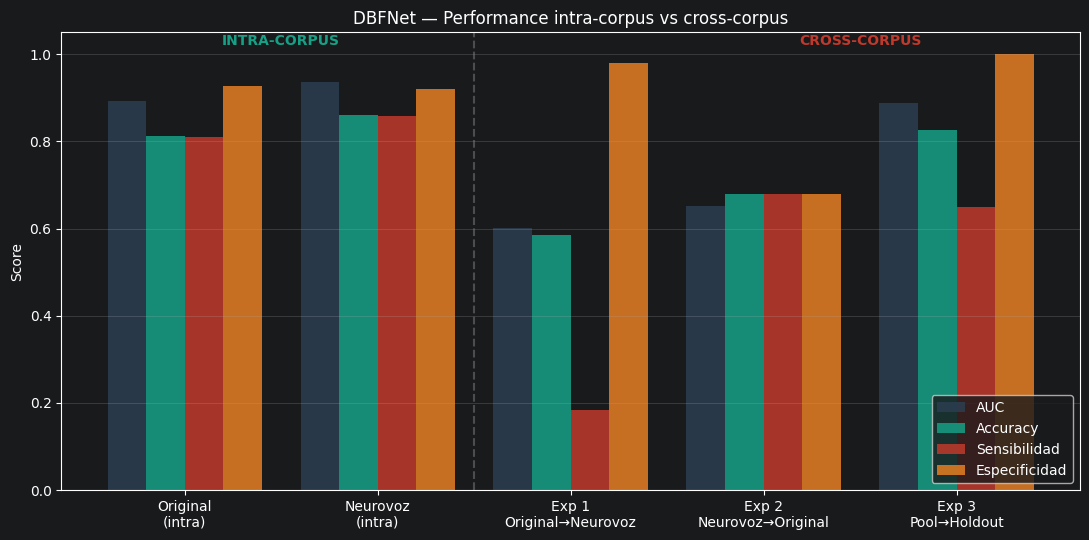

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(11, 5.5))
labels_bar = ["Original\n(intra)", "Neurovoz\n(intra)", "Exp 1\nOriginal→Neurovoz", "Exp 2\nNeurovoz→Original", "Exp 3\nPool→Holdout"]
metrics_to_plot = ["auc", "acc", "sens", "spec"]
metric_names = ["AUC", "Accuracy", "Sensibilidad", "Especificidad"]
colors = ["#2c3e50", "#16a085", "#c0392b", "#e67e22"]

x = np.arange(len(labels_bar))
width = 0.2

for i, (m, name, c) in enumerate(zip(metrics_to_plot, metric_names, colors)):
    values = [
        INTRA_CORPUS["original"][m],
        INTRA_CORPUS["neurovoz"][m],
        m_exp1[m],
        m_exp2[m],
        m_exp3[m],
    ]
    ax.bar(x + i*width - 1.5*width, values, width, label=name, color=c, alpha=0.85)

ax.set_ylabel("Score")
ax.set_title("DBFNet — Performance intra-corpus vs cross-corpus")
ax.set_xticks(x)
ax.set_xticklabels(labels_bar)
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
ax.axvline(1.5, color="gray", linestyle="--", alpha=0.5)
ax.text(0.5, 1.02, "INTRA-CORPUS", ha="center", fontsize=10, fontweight="bold", color="#16a085")
ax.text(3.5, 1.02, "CROSS-CORPUS", ha="center", fontsize=10, fontweight="bold", color="#c0392b")

plt.tight_layout()
plt.savefig("results/cross_corpus_comparison.png", dpi=120, bbox_inches="tight")
plt.show()